# [LAB-09] 1. 단순선형회귀

## #01. 준비작업

### 1. 패키지 참조

In [1]:
# 라이브러리 기본 참조
from jussam import load_data
from helper import *

# 선형회귀를 위한 참조
# -> 선형회귀 구현 방식이 두 가지 이므로 두 종류의 참조를 모두 가져온다.
from statsmodels.api import add_constant, OLS
from statsmodels.formula.api import ols as formula_ols

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('cars')
display(origin.head())      # 상위 5건 출력
display(origin.tail())      # 하위 5건 출력

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


,speed,dist
45,24,70
46,24,92
47,24,93
48,24,120
49,25,85


## #02. 탐색적 데이터 분석

### 1. 종속변수와 독립변수간의 상관분석

- origin 데이터프레임에서 speed에 대한 dist의 상관분석 수행

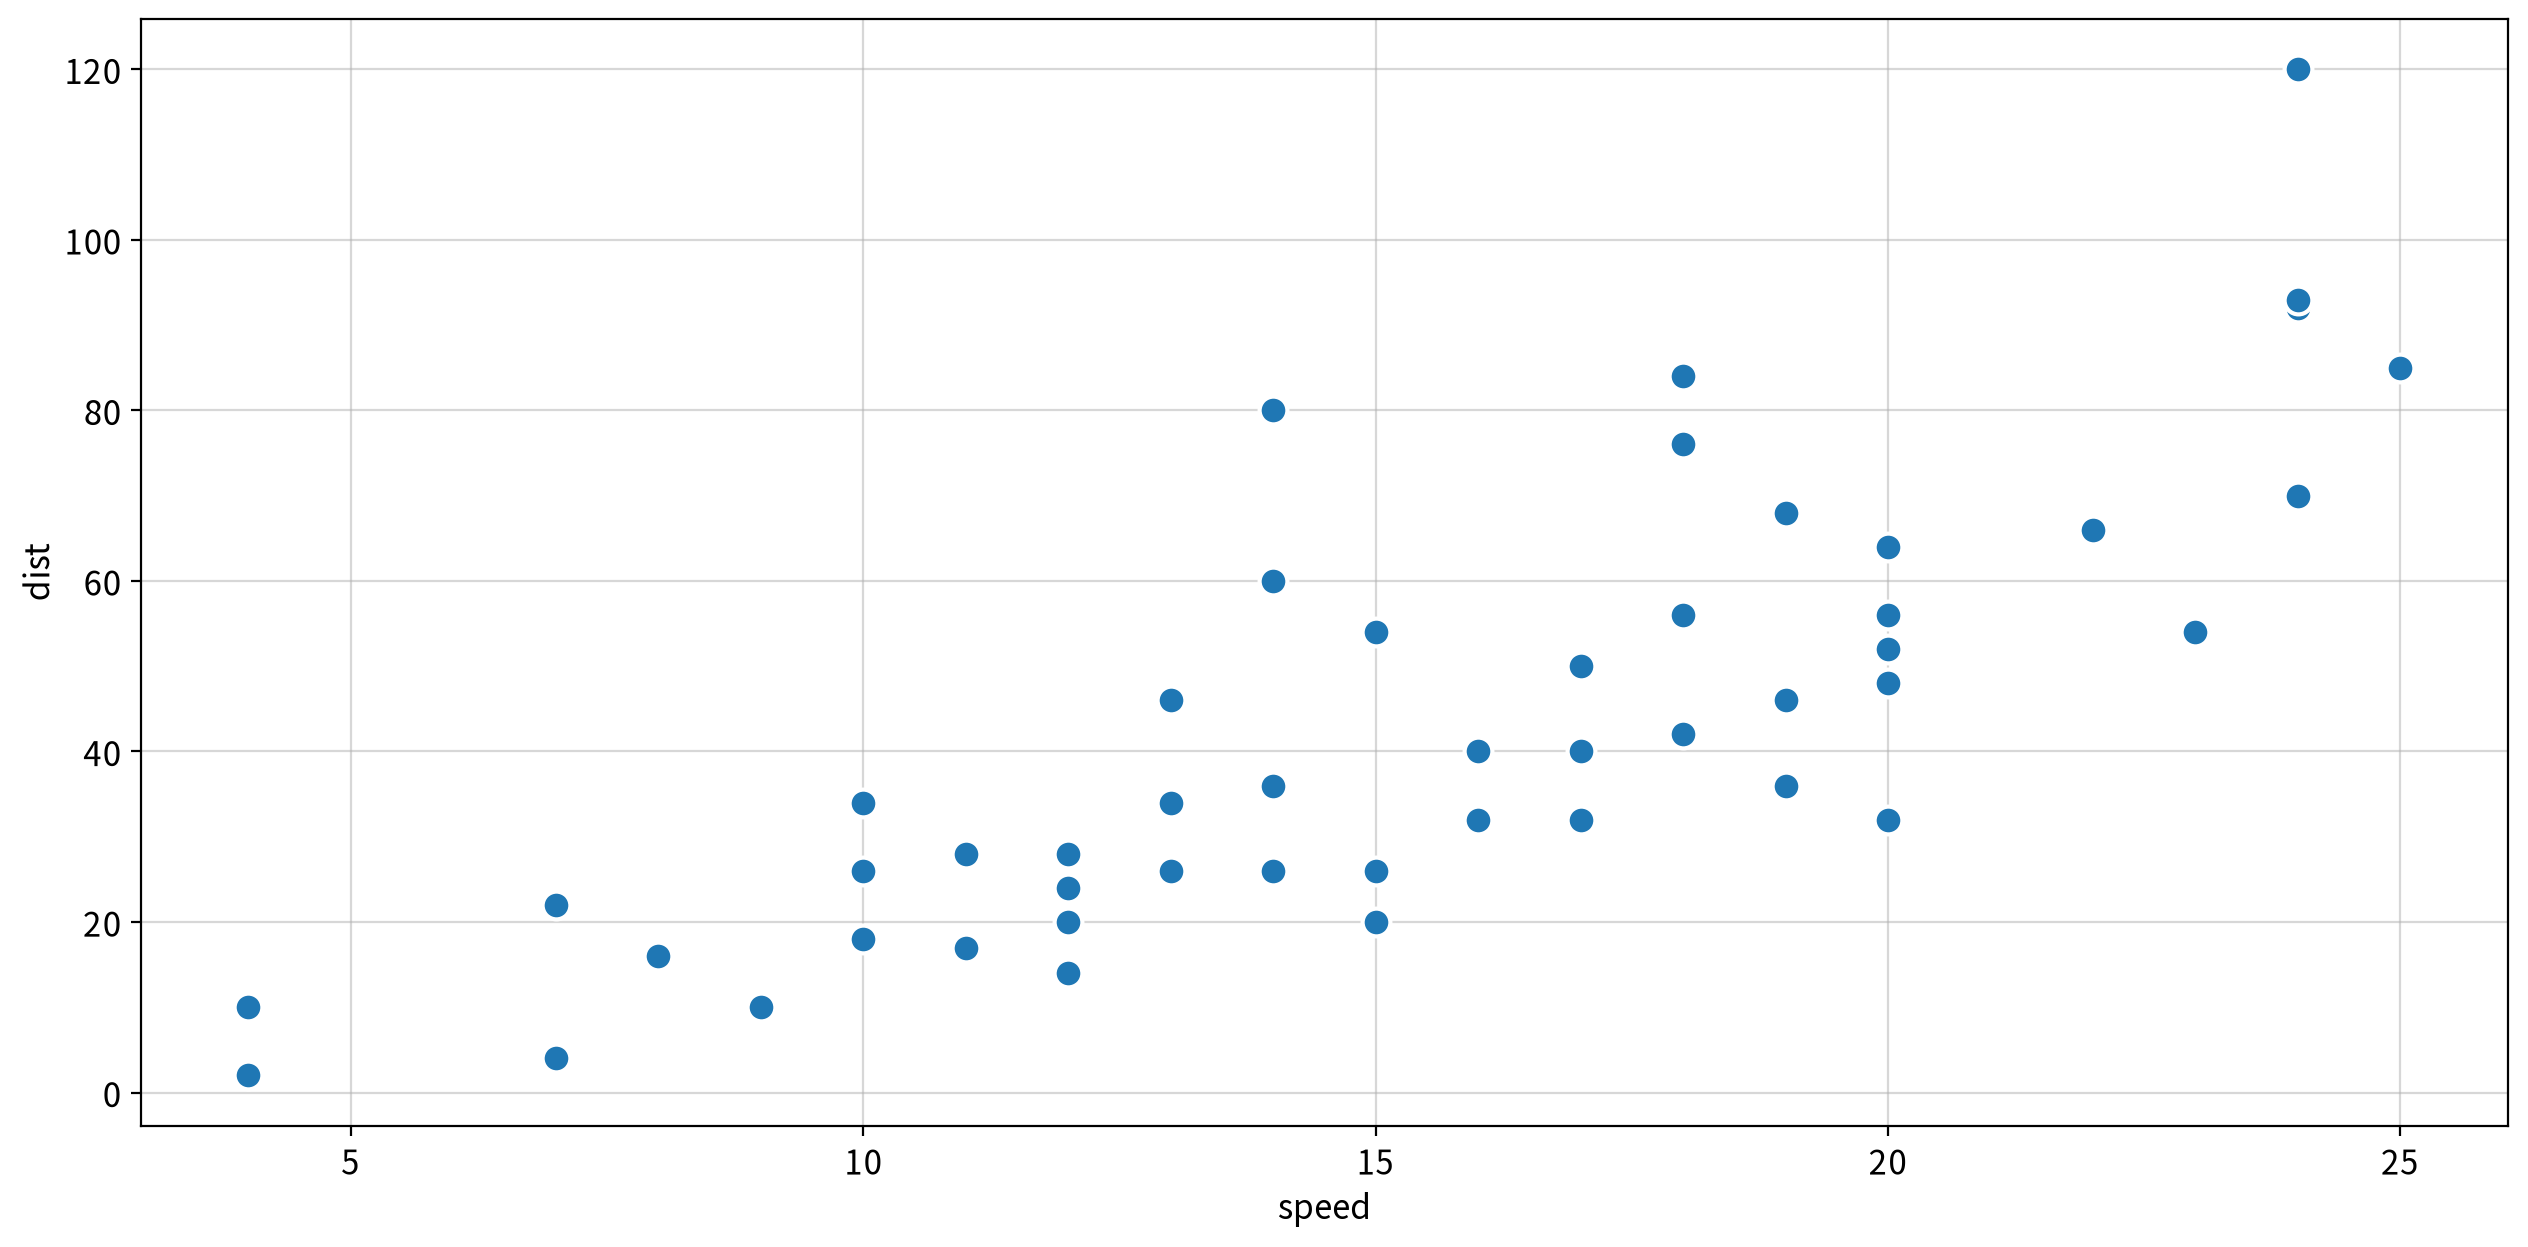

,,method,coef,strength,significant,normality,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
speed,dist,pearson,0.807,강함,True,True,True,True,False,False


In [3]:
my_stats.correlation(origin, 'speed', 'dist', plot=True)

> 자동차 속도와 제동거리는 선형성을 충족하고 양의 상관관계가 있는것으로 보인다.

## #03. 행렬기반 방식의 단순선형회귀

### 1. 독립변수 행렬 준비

- 독립변수는 행렬(=데이터프레임) 형태로 준비한다.
  - 이중 대괄호는 추출 결과가 데이터프레임이 된다.

In [4]:
x = origin[["speed"]]
x.head()

,speed
0,4
1,4
2,7
3,7
4,8


### 2. 종속변수 준비

- 종속변수는 벡터(=Series) 형태로 준비한다.
  - 단일 대괄호는 추출 결과가 Series 객체이다.

In [5]:
y = origin["dist"]
y.head()

0     2
1    10
2     4
3    22
4    16
Name: dist, dtype: int64

### 3. 상수항 추가

- $y = ax + b$ 형태가 기본형이므로 $b$ 역할을 하기 위한 상수항을 추가해야 한다.
  - 상수항이 없다면 절편이 0으로 고정된 잘못된 모델이 만들어질 수 있다.

In [6]:
x_input = add_constant(x)   # const라는 이름의 상수항 추가
x_input.head()              # 상위 5건 확인

,const,speed
0,1.000,4
1,1.000,4
2,1.000,7
3,1.000,7
4,1.000,8


### 4. 회귀분석 수행

In [7]:
# OLS 모델 객체 생성
# -> 이 단계에서는 아직 학습(fit)되지 않은 '모형의 틀'만 만들어짐
model = OLS(y, x_input)

# 모델 적합(Fit)
# -> 데이터를 이용해 회귀계수(β)를 추정하고, 모델을 완성하는 단계
fit = model.fit()

# 적합된 모델 객체의 분석 결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        11:04:51   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

## #04. formula API 방식의 선형회귀

### 1. 단순선형회귀 구현

- 상수항을 자동 처리하므로 직접 추가하지 않아도 된다.

In [8]:
# 학습 모델 객체 생성
model = formula_ols("dist ~ speed", data=origin)

# 모델적합
fit = model.fit()

# 분석결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        11:04:51   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

## #05. 실제 데이터와 모형의 예측값 비교

### 1. 원본 데이터 + 가상 데이터(예측용)

In [9]:
df = origin.copy()

# 최고 속도 이후의 5단계 값을 가상으로 추가한다.
for i in range(1,6):   # <-- i의 범위 : 1~5
    # df의 인덱스는 0부터 len(df)-1까지 존재하므로,
    # len(df) 위치에 대한 대입은 새로운 행을 추가하는 것과 동일하다.
    # -> speed 컬럼에는 최고 속도 + i 값을 대입하고, dist 컬럼에는 None을 대입한다.
    df.loc[len(df)] = [df["speed"].max() + i, None]

# 하위 10건 확인
# 마지막에 추가된 5건은 제동거리(dist) 값이 None으로 되어있다.
display(df.tail(10))

,speed,dist
45,24.000,70.000
46,24.000,92.000
47,24.000,93.000
48,24.000,120.000
49,25.000,85.000
50,26.000,NaN
51,28.000,NaN
52,31.000,NaN
53,35.000,NaN
54,40.000,NaN


### 2. 예측값 생성

분석 모형에 $x$에 해당하는 speed를 넣어 $y$에 해당하는 dist가 계산된 값

In [10]:
# 예측값을 생성하기 위해서는 상수항이 추가된 데이터를 사용해야 한다.
predict_input = add_constant(df["speed"])

# 예측값을 생성하여 pred 컬럼으로 추가한다.
df['pred'] = fit.predict(predict_input)

display(df.tail(10))   # 하위 10건 확인

,speed,dist,pred
45,24.000,70.000,76.799
46,24.000,92.000,76.799
47,24.000,93.000,76.799
48,24.000,120.000,76.799
49,25.000,85.000,80.731
50,26.000,NaN,84.664
51,28.000,NaN,92.528
52,31.000,NaN,104.326
53,35.000,NaN,120.055
54,40.000,NaN,139.717


### 3. 시각화를 위해 long 타입으로 재배치

In [11]:
df_melt = df.melt(
    id_vars="speed",
    value_vars=["dist", "pred"],
    var_name="variable",
    value_name="value"
)

display(df_melt.head(10))
display(df_melt.tail(10))

,speed,variable,value
0,4.000,dist,2.000
1,4.000,dist,10.000
2,7.000,dist,4.000
3,7.000,dist,22.000
4,8.000,dist,16.000
5,9.000,dist,10.000
6,10.000,dist,18.000
7,10.000,dist,26.000
8,10.000,dist,34.000
9,11.000,dist,17.000


,speed,variable,value
100,24.000,pred,76.799
101,24.000,pred,76.799
102,24.000,pred,76.799
103,24.000,pred,76.799
104,25.000,pred,80.731
105,26.000,pred,84.664
106,28.000,pred,92.528
107,31.000,pred,104.326
108,35.000,pred,120.055
109,40.000,pred,139.717


### 3. 시각화 비교

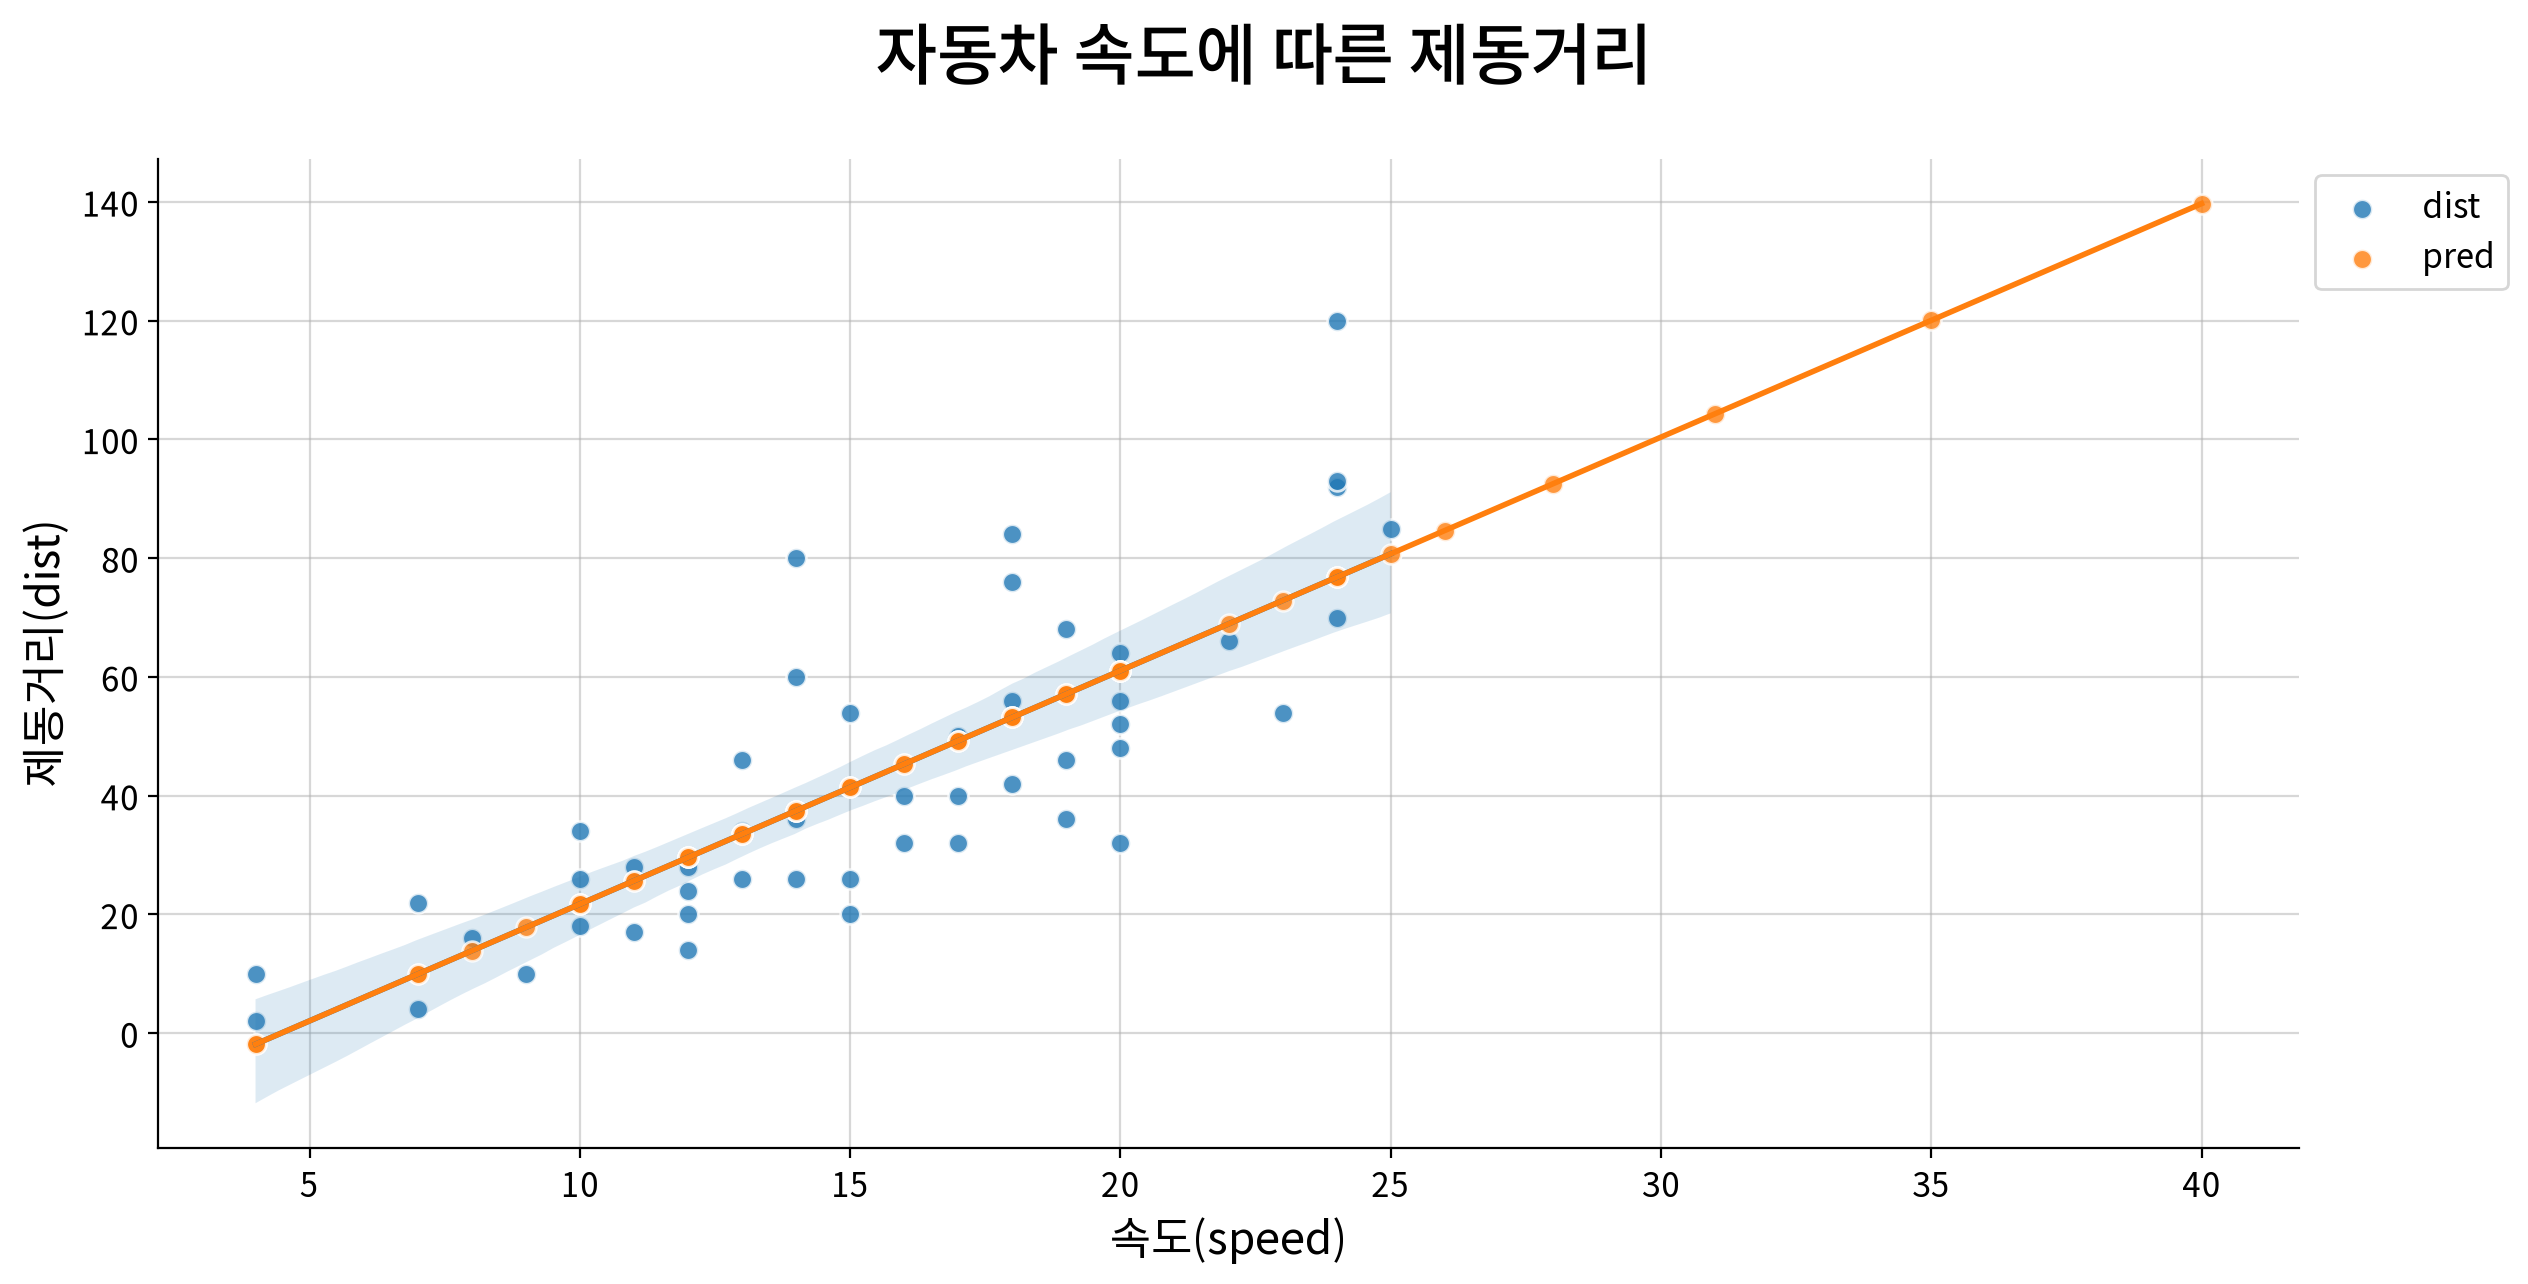

In [12]:
my_plot.lmplot(df_melt, x="speed", y="value", hue="variable", title='자동차 속도에 따른 제동거리', xlabel='속도(speed)', ylabel='제동거리(dist)')

## #05. 모듈화 기능 확인

### 1. 모델 적합

- 모듈 내부에서 상수항 추가를 자동으로 처리하도록 모듈이 구성되어 있다.

In [13]:
fit = my_ols.fit_model(origin, y='dist', summary=True)

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        11:04:51   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

### 2. 예측값 생성

In [14]:
pred = my_ols.predict(fit, origin[['speed']])

new_df = origin.copy()
new_df['pred'] = pred
new_df.head()

,speed,dist,pred
0,4,2,-1.849
1,4,10,-1.849
2,7,4,9.948
3,7,22,9.948
4,8,16,13.880


## 연습문제 1. 골턴의 유산 - 아버지의 키로 아들의 키를 예측
#### 데이터셋 : father-son

#### Mission 1. 데이터와 친해지기(EDA)
#### father-son 데이터를 불러와 크기 자료형 기초통계량 확인
#### 산점도를 그려 아버지 키와 아들 키 사이에 어떤 경향이 보이는지 눈으로 확인
#### 두 변수의 상관계수를 구하고, 회귀분석을 적용해도 되는지 근거를 대라.

In [46]:
# 라이브러리 불러오기
from jussam import load_data
from helper import *
from IPython.display import display, Markdown
from pandas import melt, DataFrame, concat

In [29]:
# 데이터 불러오기
df1 = load_data('father-son')
df1.info()
df1.head(5)

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)
<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


In [30]:
# 데이터 크기- 자료형 - 기초통계량 확인
df1.head(5)
my_qtcheck.set_type(df1)
df2 = my_qtcheck.numerical_summary(df1)
df2

<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
fheight,1078.000,67.687,2.745,59.008,65.788,67.767,69.603,75.434,0.001,similar,3.815,75.326,60.065,1,0.001,5,0.005,6,0.006,-0.088,symmetric,-0.156,platykurtic,none
sheight,1078.000,68.684,2.815,58.507,66.931,68.616,70.466,78.365,0.001,similar,3.535,75.768,61.629,8,0.007,11,0.010,19,0.018,-0.037,symmetric,0.539,leptokurtic,none


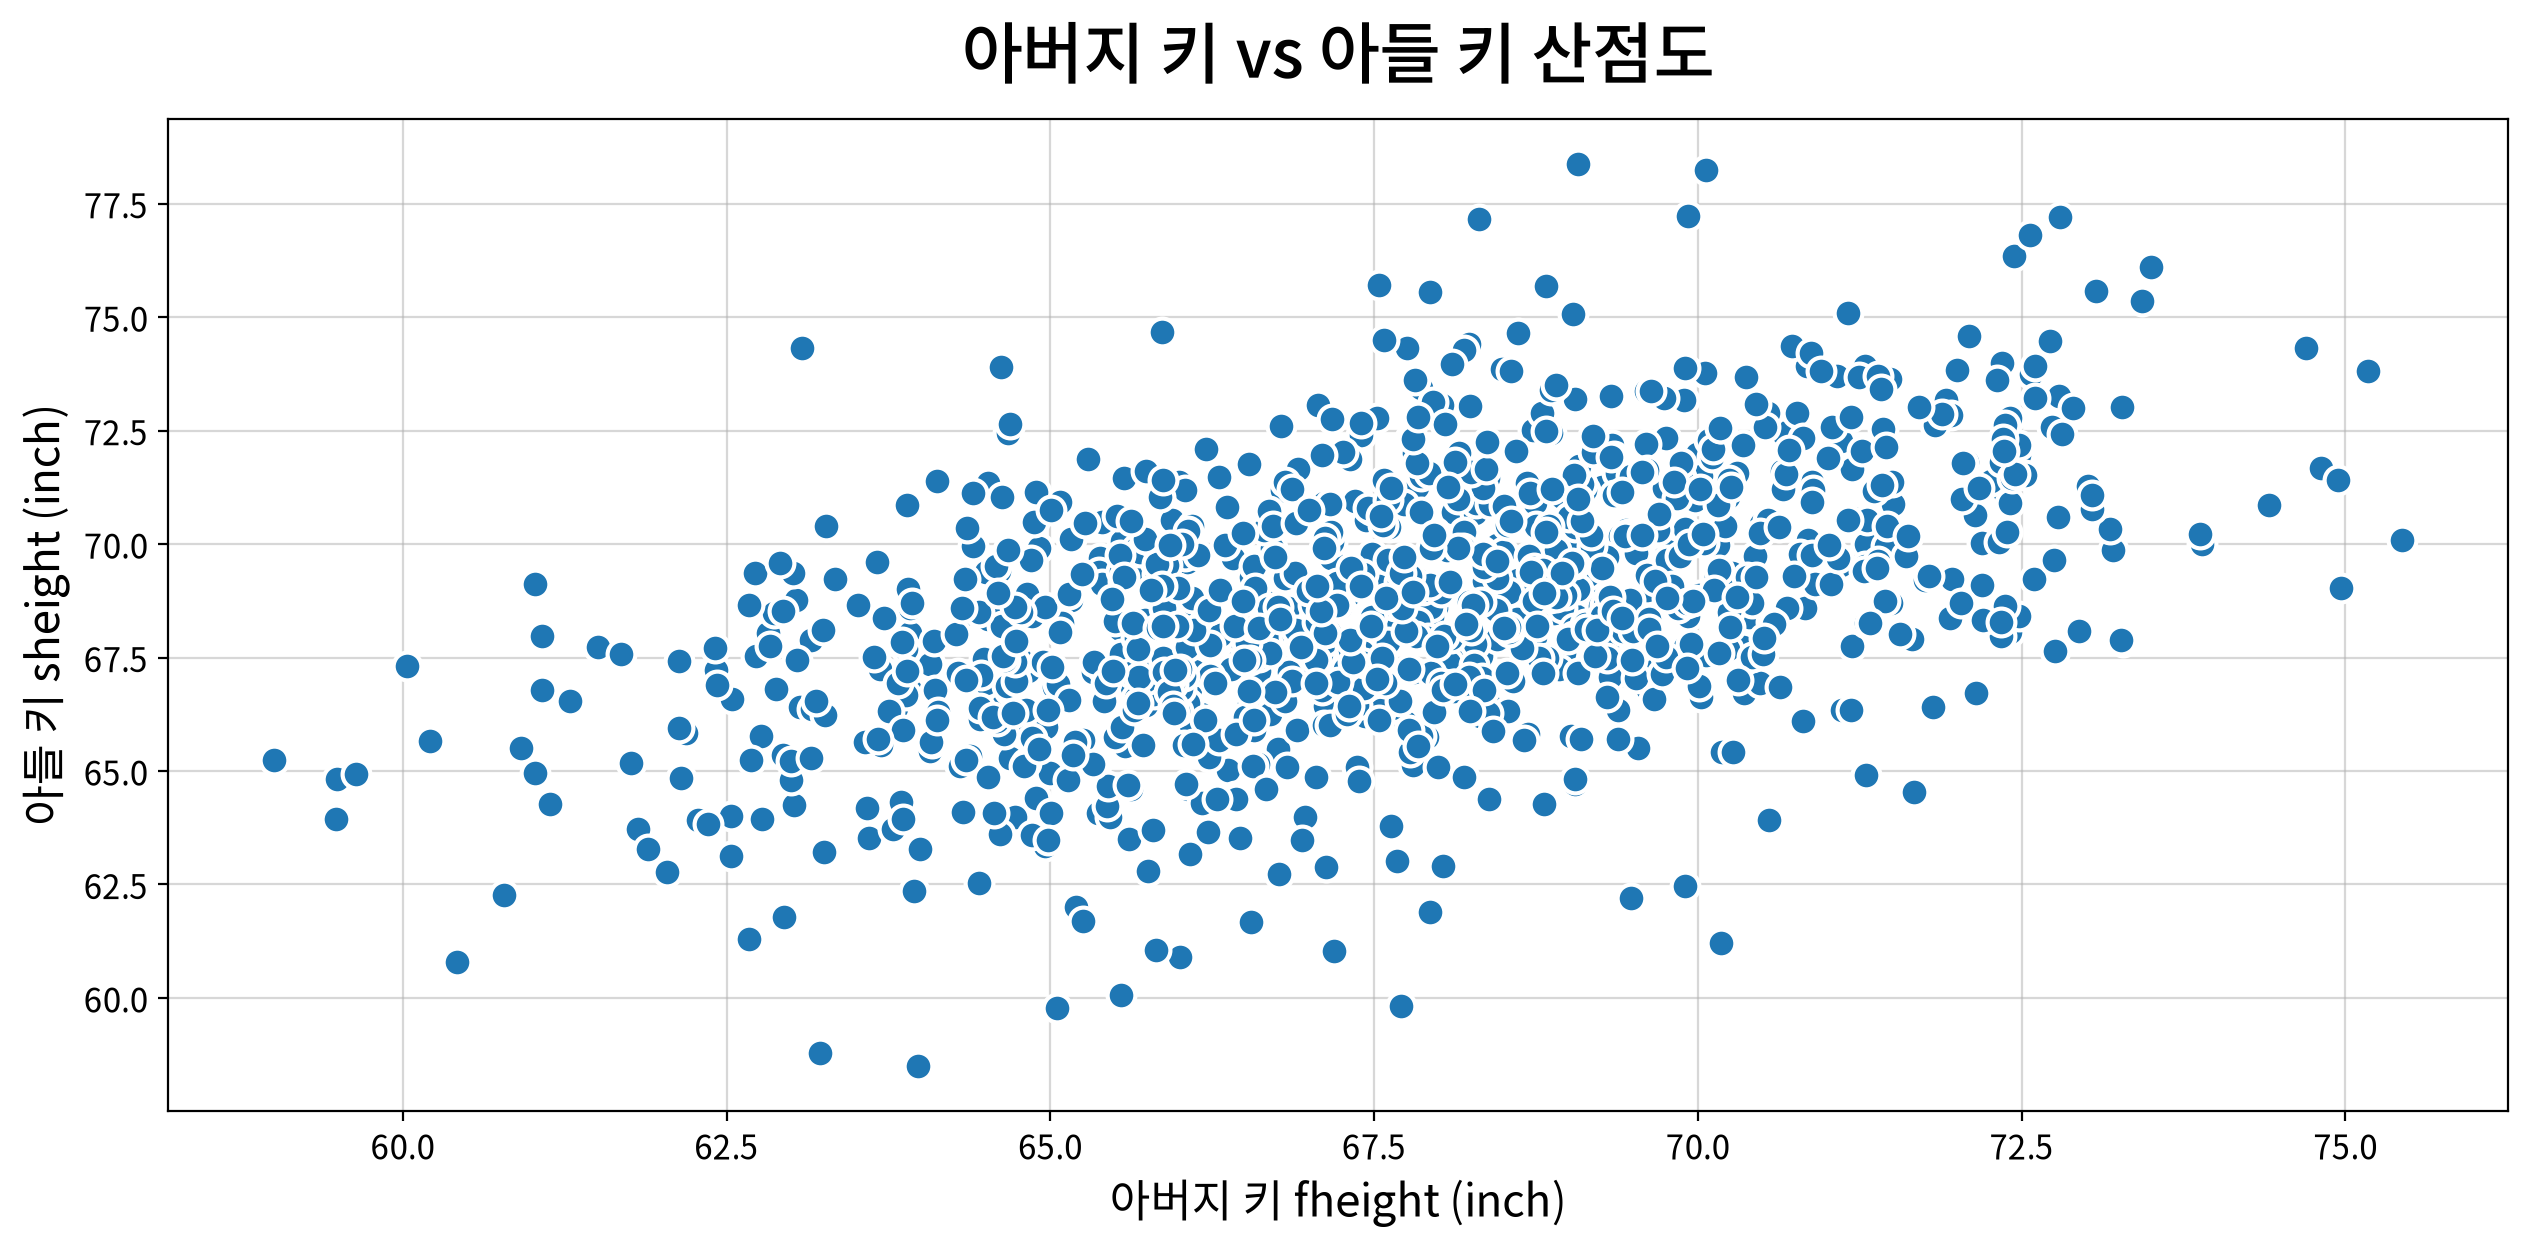

x,fheight
y,sheight
method,Spearman
coef,0.506
strength,중간
significant,True
normality,True
normality_y,False
linearity,True
influential_outlier,False
high_skew,False


In [31]:
# 상관분석 + 산점도
corr = my_stats.correlation(
    df1, x='fheight', y='sheight',
    title='아버지 키 vs 아들 키 산점도',
    xlabel='아버지 키 fheight (inch)', ylabel='아들 키 sheight (inch)',
)
corr.T

### Mission 2. 회귀식 유도
#### 아들 키(sheight)를 종속변수, 아버지 키 (fheight)를 독립변수로 하는 선형회귀 모형을 적합하라.
#### 추정 결과로부터 회귀식을 도출하여 제시하라.

In [32]:
fit = my_ols.fit_model(df1, y='sheight', summary=True)

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.12e-69
Time:                        11:25:54   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

#### 식 : y = 0.5141x + 33.8866

#### Mission 3. 소장이 건낸 새 등록 신청자 5명의 아버지키는 다음과 같다.
#### -> [73.5, 72.6, 68.3, 71.9, 74.1]
#### 가상데이터 5건과 원본데이터를 병합한 새로운 데이터셋을 만들어, 앞서 유도한 회귀식으로 각자 아들 키를 예측

In [44]:
new_fheight = [73.5, 72.6, 68.3, 71.9, 74.1]
new_f = DataFrame({'fheight': new_fheight})
new_f

,fheight
0,73.500
1,72.600
2,68.300
3,71.900
4,74.100


In [45]:
pred = my_ols.predict(fit, new_f)

new_df = new_f.copy()
new_df['sheight'] = pred['pred'].values
new_df.head(5)

,fheight,sheight
0,73.500,71.672
1,72.600,71.210
2,68.300,68.999
3,71.900,70.850
4,74.100,71.981


In [48]:
real_df = df1.copy()
real_df['source'] = '실제'
new_df['source'] = '가상'

merged = concat([real_df, new_df], ignore_index=True)

merged.tail(8)

,fheight,sheight,source
1075,71.783,69.306,실제
1076,70.738,69.302,실제
1077,70.306,67.015,실제
1078,73.500,71.672,가상
1079,72.600,71.210,가상
1080,68.300,68.999,가상
1081,71.900,70.850,가상
1082,74.100,71.981,가상


### Mission 4
#### - 실제 데이터 1078건과 가상데이터 5건을 하나의 산점도에 그려라.
#### - 실제 데이터와 가상 데이터가 색-모양으로 구분되도록 하라.
#### - 회귀 직선을 함께 그려, 5명의 예측값이 정확히 직선 위에 놓이는 것을 시각적으로 확인하라
#### - 완성된 그래프에 제목-축이름-범례를 넣어, 소장이 한눈에 이해할 수 있게 만들어라.

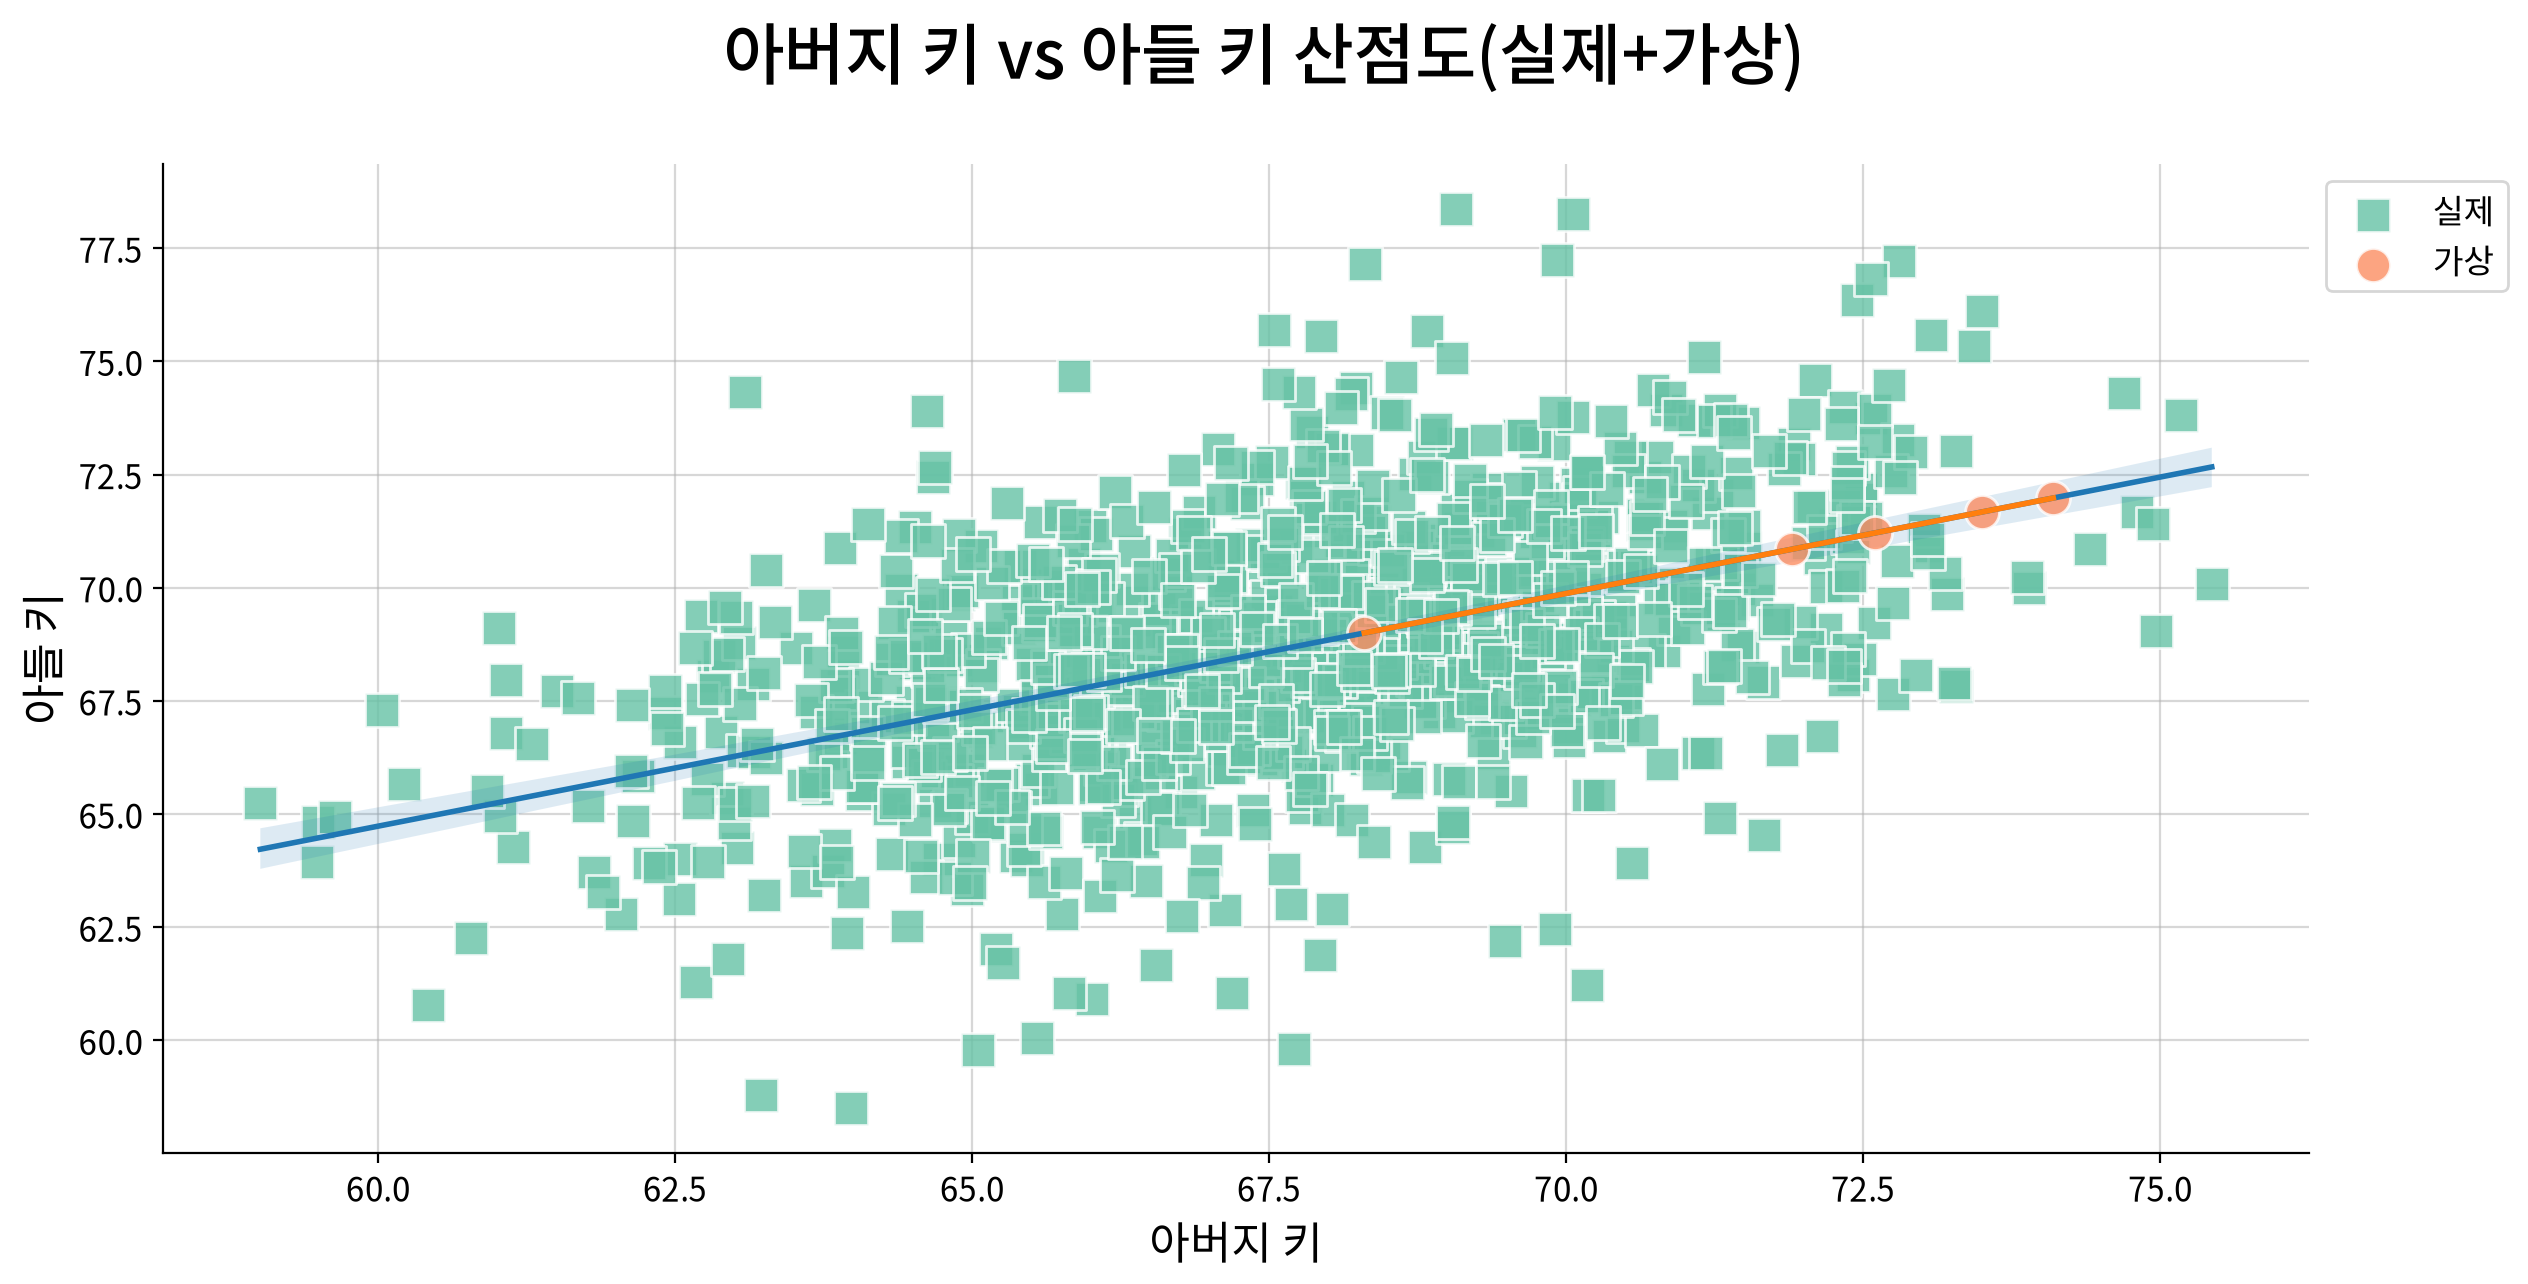

In [49]:
my_plot.lmplot(
    merged, x='fheight', y='sheight', hue='source',
    markers=['s', 'o'], palette='Set2', scatter_size=150,
    title='아버지 키 vs 아들 키 산점도(실제+가상)',
    xlabel='아버지 키', ylabel='아들 키')